# Application of MJO RMM components 
## Regressing out data fields onto the PC timeseries


```{image} ../thumbnails/thumbnail.png
:alt: Project Pythia logo
:width: 100px
```

*This workflow extends the spectral analysis cookbook by translating spectral techniques into dynamical representations of the MJO. It forms the foundation for diagnosing and quantifying the MJO and serves as a basis for extending the analysis toward regional impacts, predictability, and model evaluation.* 


## Learning Outcomes

By the end of this tutorial, you will be able to:

##### Connect spectral analysis techniques introduced in the previous EOF tutorial (**link notebook**) to MJO diagnostics.
- Relate EOF-derived principal components to the RMM index.
- Interpret the physical meaning of RMM1 and RMM2.
- Construct and analyze an RMM phase-space diagram.
- Identify the phase and amplitude of MJO events from observational datasets.

  

## Overview

The **Madden–Julian Oscillation (MJO)** is an eastward-propagating tropical disturbance characterized by large-scale anomalies in atmospheric circulation and deep convection. The MJO typically propagates around the globe on timescales of 30–60 days and plays an important role in modulating tropical and extratropical weather patterns.

```{figure} images/MJO_anim_full.gif
:alt: sample phase diagram
:width: 500px
:name: mjo-anim

Example of an MJO event observed (spring 2005). Enhanced rainfall conditions (green) and suppressed rainfall conditions (brown) form a large-scale pattern that propagates eastward across the tropics. The pattern revisits a given location after approximately 45 days, illustrating the characteristic intraseasonal timescale of the MJO ([Source - climate.gov](https://www.climate.gov/media/13490)).
```
Its state is commonly described using the **Real-time Multivariate MJO (RMM) index**, which is derived from the leading two multivariate empirical orthogonal functions (EOFs) of equatorially averaged outgoing longwave radiation (OLR) and zonal winds at 200 hPa and 850 hPa, following Wheeler and Hendon RMM Index ([Wheeler and Hendon, 2004](https://doi.org/10.1175/1520-0493(2004)132,1917:AARMMI.2.0.CO;2.)). The RMM index defines eight phases (1–8, see Figure 2) that represent the canonical eastward progression of MJO-related convection and circulation anomalies around the tropics. Phases 1–4 correspond primarily to enhanced convection over the Indian Ocean, while phases 5–8 indicate active MJO conditions over the western Pacific ([Kiladis et al., 2014](https://doi.org/10.1175/MWR-D-13-00301.1.)).

```{figure} images/Approximate-locations-of-the-MJO.jpg
:alt: location of MJO
:width: 500px
:name: location of MJO

 Locations of the MJO centre of convection RMM Index phases 1-8.([Adapted from Donald, et al, 2004](https://agronomyaustraliaproceedings.org/images/sampledata/2004/poster/2/6/1362_donalda.pdf)).
```
The evolution of an MJO event is commonly visualized using an RMM phase-space diagram, where the horizontal and vertical axes correspond to RMM1 and RMM2, respectively. Successive points trace the eastward propagation of the MJO through the eight phases. The amplitude of the MJO is represented by the distance from the origin in the RMM phase space.

```{figure} images/sample_phase_daigram.png
:alt: sample phase daigram
:width: 500px
:name: sample phase daigram

Example of an MJO phase daigram representing the propagation of MJO([Source-mjoclivar](https://www.ncl.ucar.edu/Applications/mjoclivar.shtml)).
```

In this tutorial, we will apply the spectral and EOF analysis techniques introduced in the previous tutorial (**link**) to the study of the MJO. Using observed atmospheric fields, we will reproduce the leading modes of tropical intraseasonal variability and explore how the RMM index is constructed.

The expected learn oucome is; 
- the application of EOF analysis we learned **link the repo** in context of the MJO.


## Prerequisites

### An understanding of the different spectral techniques.

Review the basis of spectral analaysis from earlier notebooks;

    - Harmonic analysis to calculate the seasonal anomalies.
    - Bandpass filtering to filter out the intraseasonal variability
    - The EOF analysis to construct the RMM1 (PC1) and RMM2 (PC2) components.
    
The learners are expected to have the constructed RMM1 and RMM2 components. these can either be downloaded from Australian Bureau of Meteorology; or can be constructed using your own data (model data) using the tutorial here (**link the notebook**).

### Data Access

1. RMM index data were obtained from the Australian Bureau of Meteorology: [Link](http://www.bom.gov.au/climate/mjo/graphics/rmm.74toRealtime.txt).
   
Or if you want to compute these indices with your data:
1. Follow the tutuorial our earlier tutorial on the RMM index calculation (**Link the repo**)
1. global 3-D field (OLR, U850, U200, geopotential height,..) can be downloaded using the [notebook](spectral-analysis-cookbook/notebooks/SpectralAnalysisDataSetAccess.ipynb)


:::{note}
The tutorial on the RMM index calculation is still a work in progress!
:::


## Workflow

1. Once we have our RMM1 (PC1) and RMM2 (PC2) components; a common practice to visualize the MJO propagation is the MJO phase diagram. So our first step will be,
   - plotting MJO phase diagrams
1. Regression onto the Principal Components
    - Regress each global 3-D field (OLR, U850, U200, geopotential height,...) on RMM1 and RMM2.
        - Before regressing, we have to preprocess the data to isolate the MJO signal. Common practices include(do not need),
            -  remove the seasonal cycle (by removing the first three harmonics). - **add link**
            -  remove the ENSO signal (Regressing out the first two EOF components of the Sea Surface Temperature)
            -  Substracting a 120 days running mean.
        - Once we have isolated the MJO signals; we can regress our RMM components on to different fields like OLR, winds and etc.  
    - Reconstruct the MJO life cycle by taking linear combinations of the two regression maps: -PC2, (PC1 - PC2)/sqrt(2), PC1, (PC1 + PC2)/sqrt(2), PC2.
    - Compare the reconstructed maps with Wheeler and Hendon (2004) and Adames and Wallace (2014).

## Imports

In [1]:
import pandas as pd
import numpy as np
import requests
from io import StringIO
import s3fs
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import cartopy.crs as ccrs
import cartopy.feature as cfeature




## Functions

In [2]:
# hide-cell

# function to download MJO indices
def load_mjo(url, kind="rmm"):
    """
    Unified loader for MJO indices: RMM or OMI.

    Returns standardized dataframe:
    index = datetime
    columns = pc1, pc2, phase, amplitude
    """

    headers = {"User-Agent": "Mozilla/5.0"}
    r = requests.get(url, headers=headers)
    r.raise_for_status()
    data = StringIO(r.text)

    if kind.lower() == "rmm":

        df = pd.read_csv(
            data,
            sep=r"\s+",
            header=None,
            skiprows=2,
            engine="python"
        )

        df = df.iloc[:, :7]
        df.columns = ["year", "month", "day", "pc1", "pc2", "phase", "amplitude"]

    elif kind.lower() == "omi":

        df = pd.read_csv(
            data,
            sep=r"\s+",
            header=None,
            comment="#",
            engine="python"
        )

        df = df.iloc[:, :7]
        df.columns = ["year", "month", "day", "hour", "pc1", "pc2", "amplitude"]

    else:
        raise ValueError("kind must be 'rmm' or 'omi'")

    # datetime index
    df["date"] = pd.to_datetime(df[["year", "month", "day"]])
    df = df.set_index("date")

    # --- OMI: compute phase if needed ---
    if kind.lower() == "omi":
        angle = np.arctan2(df["pc2"].values, df["pc1"].values)
        df["phase"] = ((np.degrees(angle) + 360) % 360 // 45 + 1).astype(int)

    # select standard output
    return df[["pc1", "pc2", "phase", "amplitude"]]


# function to remove seasonal cycles    
def remove_seasonal_cycle_harmonic(data, n_harmonics=4, year_period=365.25):
    """
    Remove seasonal cycle using harmonic regression.

    Parameters
    ----------
    data : ndarray
        3D array with shape (time, lat, lon). No NaN values.
    n_harmonics : int
        Number of harmonic pairs (sin/cos) to fit.
    year_period : float
        Period of the seasonal cycle in time units.

    Returns
    -------
    anomalies : ndarray
        Data with seasonal cycle removed, same shape as input.
    """

    n_time, n_lat, n_lon = data.shape
    data_2d = data.reshape(n_time, -1)

    # Build design matrix
    t = np.arange(n_time)
    X = np.ones((n_time, 2 * n_harmonics + 1))

    for i in range(1, n_harmonics + 1):
        X[:, 2*i - 1] = np.sin(i * 2 * np.pi * t / year_period)
        X[:, 2*i] = np.cos(i * 2 * np.pi * t / year_period)

    # Least-squares fit
    coeffs = np.linalg.lstsq(X, data_2d, rcond=None)[0]

    # Remove seasonal cycle
    anomalies = data_2d - X @ coeffs

    return anomalies.reshape(n_time, n_lat, n_lon)


## Getting started

The RMM index data used in this tutorial were obtained from the Australian Bureau of Meteorology (see below). Alternatively, you can compute the RMM index yourself by following our RMM Index Calculation tutorial (**link to notebook**).

Let's read the data and get started!

In [3]:
url_rmm = "https://www.bom.gov.au/climate/mjo/graphics/rmm.74toRealtime.txt"

rmm = load_mjo(url_rmm, kind="rmm")
rmm.index.name = "time"

#rmm.head()

# now print the time period
print("\nRMM available period:")
print(rmm.index.min(), "to", rmm.index.max())

#slice the data for desired time
common_start = '1990-01-01'
common_end = '2024-02-24'
rmm = rmm.loc[common_start:common_end]

# now print again
print("\nRMM period:")
print(rmm.index.min(), "to", rmm.index.max())


RMM available period:
1974-06-01 00:00:00 to 2024-02-24 00:00:00

RMM period:
1990-01-01 00:00:00 to 2024-02-24 00:00:00


The required atmospheric fields (e.g., OLR, U850, U200, and geopotential height) can be downloaded using the following,

In [4]:
URL = 'https://js2.jetstream-cloud.org:8001/' #Locate and read a file
fs = s3fs.S3FileSystem(anon=True, client_kwargs=dict(endpoint_url=URL))

olr_noaa_store = s3fs.S3Map(
    root=f'pythia/olr_noaa.zarr',
    s3=fs,
    check=False
)

# Open with xarray
olr_noaa = xr.open_zarr(olr_noaa_store)
olr_noaa

# Make sure time is sorted
olr_noaa = olr_noaa.sortby("time")

# Check variable names
print(olr_noaa.data_vars)


Data variables:
    __xarray_dataarray_variable__  (time, lat, lon) float32 242MB dask.array<chunksize=(1024, 25, 144), meta=np.ndarray>


## The MJO RMM Index

### Comparison of RMM PCs
Now lets quickly plot the components first; then lets do a phase daigram for an event;

Text(0.5, 1.0, 'Comparison of RMM1 and RMM2')

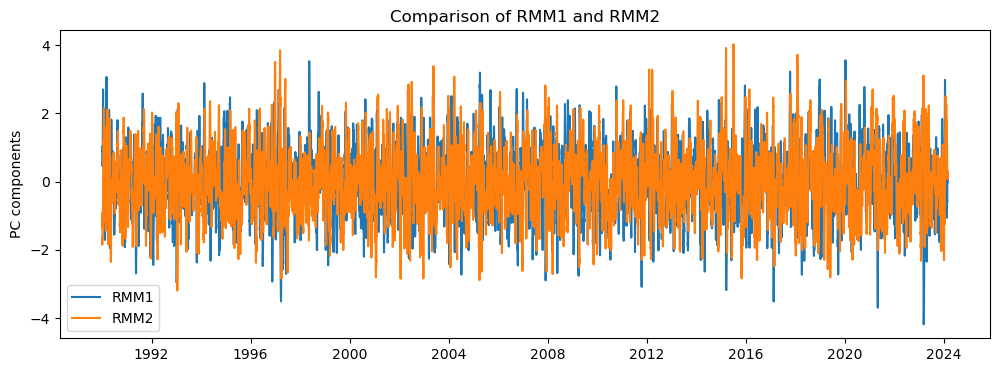

In [5]:
fig, ax = plt.subplots(figsize=(12,4))

ax.plot(rmm.index, rmm["pc1"],label="RMM1")
ax.plot(rmm.index, rmm["pc2"],label="RMM2")

ax.legend()
ax.set_ylabel("PC components")
ax.set_title("Comparison of RMM1 and RMM2")
    

### The RMM amplitude

The RMM amplitude is often smoothed using a running mean to emphasize low-frequency variability (2-10 days) and highlight periods of sustained MJO activity. Here, we apply a 10-day running mean to the daily RMM amplitude. 

Periods where the smoothed amplitude exceeds 1 indicate active MJO conditions, while values below 1 correspond to weak or incoherent MJO signals. The resulting time series provides a simple way to identify intervals of enhanced intraseasonal variability.

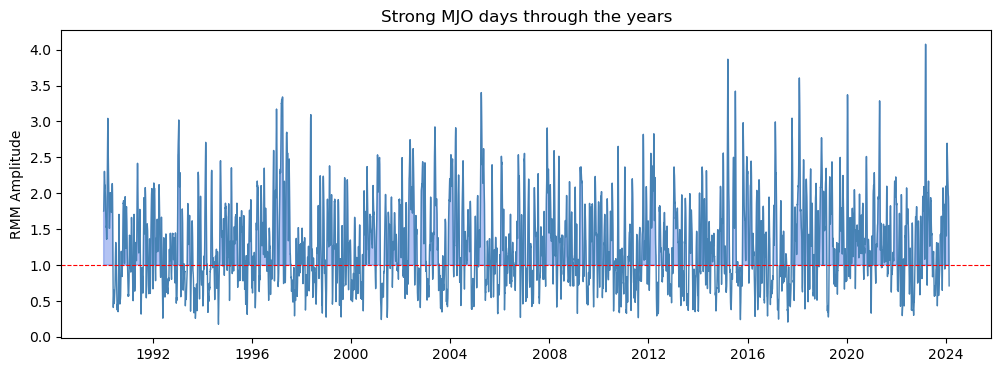

In [6]:
# 6-day running mean
rmm_smooth = rmm.rolling(window=10, center=True).mean()

fig, ax = plt.subplots(figsize=(12,4))

ax.plot(rmm_smooth.index, rmm_smooth["amplitude"], color="steelblue", lw=1)

# fill in for active/strong MJOs
ax.fill_between(rmm_smooth.index, 1, rmm_smooth["amplitude"], where=rmm_smooth["amplitude"] > 1,
    color="royalblue", alpha=0.4)

ax.axhline(1, color="r", lw=0.8, ls="--")
ax.set_ylabel("RMM Amplitude")
ax.set_title("Strong MJO days through the years")

plt.show()


### The RMM Phase Diagram for a season

As mentioned earlier, the state of the MJO can be represented by the two principal components of the RMM index, RMM1 and RMM2. Plotting these components against one another produces the RMM phase-space diagram, one of the most widely used tools for tracking the evolution of MJO events.

In the phase-space diagram, each point corresponds to a single day, with the trajectory showing how the MJO evolves through time. The eight sectors of the diagram represent the canonical eastward progression of MJO-related convection around the tropics. The distance from the origin indicates the strength of the MJO signal, while the angular position determines its phase.

The dashed unit circle marks an amplitude of one. Points outside this circle are typically considered to represent an active and coherent MJO event, whereas points inside the circle indicate weak or poorly organized intraseasonal variability.

In the example below, we examine the period from December 2023 through February 2024 (DJF 2023–24). The trajectory is colored by date, allowing the temporal evolution of the event to be visualized directly in phase space. By following the progression of colors, one can identify periods of amplification, weakening, and eastward propagation through the eight MJO phases.

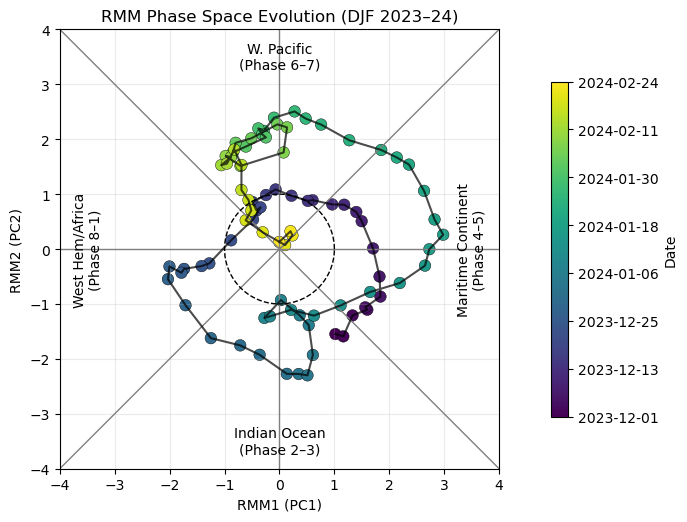

In [7]:
start = "2023-12-01"
end   = "2024-02-24"

rmm_event = rmm.loc[start:end]

fig, ax = plt.subplots(figsize=(7,7))

dates = rmm_event.index  # assumes DatetimeIndex
#t = np.arange(len(rmm_event))

# zero lines (phase separation)
ax.axhline(0, color="gray", lw=1)
ax.axvline(0, color="gray", lw=1)
ax.plot([4, -4], [4, -4], color="gray", lw=1)
ax.plot([4, -4], [-4, 4], color="gray", lw=1)

# trajectory line
ax.plot(rmm_event["pc1"], rmm_event["pc2"], color="k", lw=1.5, alpha=0.7)

# colored evolution
sc = ax.scatter(
    rmm_event["pc1"],
    rmm_event["pc2"],
    c=mdates.date2num(dates),   # convert datetime → numeric
    cmap="viridis",
    s=70,
    edgecolor="k",
    linewidth=0.3
)

# unit circle (reference)
theta = np.linspace(0, 2*np.pi, 300)
ax.plot(np.cos(theta), np.sin(theta), 'k--', lw=1)

# axes limits
ax.set_xlim(-4, 4)
ax.set_ylim(-4, 4)

# quadrant labels (MJO phase guide)
ax.text(0,  3.5, "W. Pacific\n(Phase 6–7)", ha="center", va="center")
ax.text(3.5, 0, "Maritime Continent\n(Phase 4–5)", ha="center", va="center", rotation="vertical")
ax.text(0,-3.5, "Indian Ocean\n(Phase 2–3)", ha="center", va="center")
ax.text(-3.5, 0, "West Hem/Africa\n(Phase 8–1)", ha="center", va="center", rotation="vertical")

# formatting
ax.set_aspect("equal", adjustable="box")
ax.set_title("RMM Phase Space Evolution (DJF 2023–24)")
ax.set_xlabel("RMM1 (PC1)")
ax.set_ylabel("RMM2 (PC2)")

ax.grid(alpha=0.25)


cbar = plt.colorbar(sc, ax=ax, pad=0.09, shrink=0.5 )
cbar.set_label("Date")

# format colorbar ticks as dates
tick_locs = np.linspace(mdates.date2num(dates[0]), mdates.date2num(dates[-1]), 8)

cbar.set_ticks(tick_locs)
cbar.set_ticklabels([mdates.num2date(t).strftime("%Y-%m-%d") for t in tick_locs])

plt.tight_layout()
plt.show()

Interpreting an RMM phase-space diagram involves considering both the phase and the amplitude of the MJO. A complete MJO event is often characterized by a counterclockwise progression through multiple phases while remaining outside the unit circle for an extended period.

## Preprocessing different fields to isolate the MJO signal. 

As mentioned earlier, the common practices include,
- remove the seasonal cycle (by removing the first three harmonics). - add link
- remove the ENSO signal (Regressiong out the first two EOF components of the Sea Surface Temperature)- we wont be doing this, but follow our EOF tutorial **add link** if you are required to do so.
- Substracting a 120 days running mean.

### Step 1: Handling Missing Values in OLR Data

Before performing the harmonic analysis, it is essential to ensure that the input field is temporally continuous and free of missing values. Missing data can introduce artificial variance and distort the resulting spectral analysis.

In this step, we first identify days where the entire spatial field is missing and then apply temporal interpolation to fill gaps in the dataset. We begin by extracting the OLR variable from the dataset:

In [8]:

# Optional: check which days have all missing OLR data
da = olr_noaa["__xarray_dataarray_variable__"]

spatial_dims = [d for d in da.dims if d != "time"]

bad_days = da.isnull().all(dim=spatial_dims).compute()
#print("Days with all missing data:")
#print(da.time.where(bad_days, drop=True).values)

# Rechunk so time is one chunk
olr_noaa_chunked = olr_noaa.chunk({"time": -1})

# Linear interpolation along time
olr_noaa_filled = olr_noaa_chunked.interpolate_na(
    dim="time",
    method="linear"
)

## Uncomment, if you want to plot it  
# Plot one day (with only NaN data)
#missing_day = np.datetime64("1980-06-04T12:00:00")
#olr_noaa_filled["__xarray_dataarray_variable__"].sel(time=missing_day).plot(x="lon", y="lat", cmap="RdBu_r")
#plt.title(f"Interpolated OLR on {missing_day}")
#olr_noaa_filled.to_array("olr")

olr_noaa_da = olr_noaa_filled["__xarray_dataarray_variable__"]
#olr_noaa_da


### Step 2: Removing the seasonal cycle

The next step is to remove the dominant seasonal cycle from the OLR field. This is necessary because the seasonal cycle is much larger in magnitude than the intraseasonal variability associated with the MJO and can obscure the signal of interest.

A common approach is to remove the first few harmonics of the climatological annual cycle. In this tutorial, we follow the standard MJO preprocessing approach of removing the seasonal cycle using a harmonic fit (first 3–4 harmonics of the annual cycle). This approach effectively removes the mean annual cycle along with its strongest higher-order components while retaining intraseasonal variability.

For details on harmonic decomposition, see **add link** the earlier tutorial.

In [9]:
olr_ano = remove_seasonal_cycle_harmonic(olr_noaa_da.values, n_harmonics=4, year_period=365.25)

type(olr_ano)
# changing the type to perform running mean
olr_ano_xr = xr.DataArray(
    olr_ano,
    coords=olr_noaa.coords,
    dims=olr_noaa.dims,
    name="olr_anom"
)

The resulting field represents OLR anomalies with respect to the seasonal climatology and is the basis for subsequent intraseasonal filtering.

### Step 3: Removing Low-Frequency Variability (120-day running mean)

Even after removing the seasonal cycle, the OLR field still contains variability on longer timescales such as ENSO and low-frequency background fluctuations. To isolate the intraseasonal band associated with the MJO, we subtract a 120-day running mean. This step acts as a high-pass filter, removing variability longer than ~90–120 days while retaining the 20–100 day MJO band.

In [10]:
# 120-day running mean
rmm_smooth_120 = olr_ano_xr.rolling(time=120, center=True).mean()
# substract the running mean

olr_mjo = olr_ano_xr - rmm_smooth_120

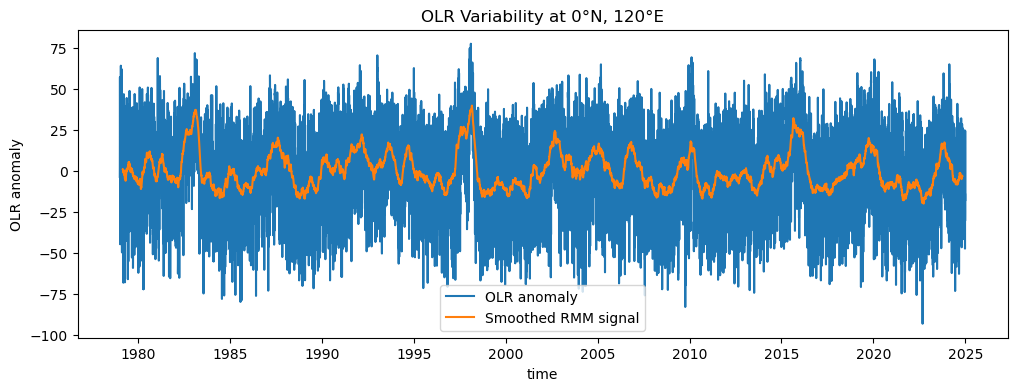

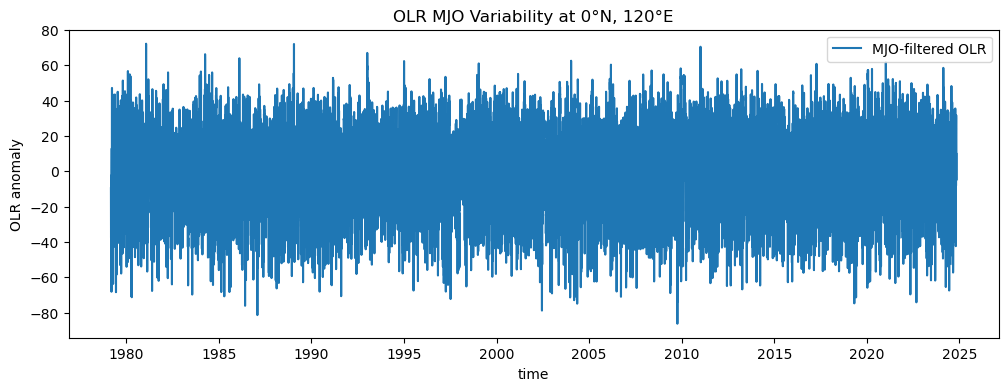

In [11]:
# ploting the results for a location.

point = olr_ano_xr.sel(lat=0.0, lon=120.0, method="nearest")
point2 = rmm_smooth_120.sel(lat=0.0, lon=120.0, method="nearest")
point1 = olr_mjo.sel(lat=0.0, lon=120.0, method="nearest")

fig, ax = plt.subplots(figsize=(12,4))

point.plot(ax=ax, label="OLR anomaly")
point2.plot(ax=ax, label="Smoothed RMM signal")

ax.set_title("OLR Variability at 0°N, 120°E")
ax.set_ylabel("OLR anomaly")

ax.legend()
plt.show()

fig, ax = plt.subplots(figsize=(12,4))

point1.plot(ax=ax, label="MJO-filtered OLR")

ax.set_title("OLR MJO Variability at 0°N, 120°E")
ax.set_ylabel("OLR anomaly")

ax.legend()
plt.show()

At a fixed tropical location, the raw OLR anomaly contains both high-frequency weather noise and low-frequency variability. After applying MJO-specific filtering, the signal becomes more coherent and exhibits clearer intraseasonal oscillations. Comparing these time series illustrates how successive preprocessing steps progressively isolate the MJO signal.

This location lies within the Maritime Continent region, where MJO-related convection exhibits strong modulation and rapid transitions between active and suppressed phases.


### Step 4: Converting RMM indices into xarray format and aligning datasets
To facilitate consistent analysis between the OLR-based MJO field and the RMM index, all datasets are converted into a common xarray format with aligned time coordinates. This ensures that time series operations (correlation, regression, composites) can be performed without mismatches.

First, we extract the RMM principal components and then we convert them into xarray.DataArray objects using the original time index, then standardize the time co-ordinates. Finally, we align all datasets along the time dimension using an inner join, ensuring that only common timestamps are retained.  

In [12]:
pc1 = rmm["pc1"]
pc2 = rmm["pc2"]

# convert them into xarray.DataArray objects
pc1_xr = xr.DataArray(pc1.values, dims=[pc1.index.name],coords={pc1.index.name: pc1.index},name="pc1")
pc2_xr = xr.DataArray( pc2.values, dims=[pc2.index.name], coords={pc2.index.name: pc2.index}, name="pc2")

# Standardizing time coordinates
olr_mjo["time"] = olr_mjo.time.dt.floor("D")

# restrict all datasets to a common analysis period
olr_mjo = olr_mjo.sel(time=slice(common_start, common_end))

# print and check
#print(len(rmm))
#print(len(olr_mjo.time))
#print(rmm.index.min(), rmm.index.max())
#print(olr_mjo.time.min().values, olr_mjo.time.max().values)

# Aligning datasets
olr_mjo, pc1_xr, pc2_xr = xr.align(olr_mjo, pc1_xr, pc2_xr, join="inner")

##  Regressing PC components onto the fields.

Once the MJO signal has been isolated, we can examine its spatial structure by regressing the RMM principal components onto atmospheric fields such as OLR, zonal winds, or precipitation. This allows us to reconstruct the typical spatial pattern associated with each phase of the MJO.

For a two-dimensional field S(x,y,t) (e.g., OLR anomalies), the linear regression onto the RMM components is written as:
\begin{align}
OLR'(x,y,t) &= a(x,y)\,\text{RMM1}(t) + b(x,y)\,\text{RMM2}(t)
\end{align}

\begin{align}
a(x,y) &= \frac{\mathrm{cov}\big(OLR(x,y,t), \text{RMM1}(t)\big)}{\mathrm{var}(\text{RMM1}(t))} \\
b(x,y) &= \frac{\mathrm{cov}\big(OLR(x,y,t), \text{RMM2}(t)\big)}{\mathrm{var}(\text{RMM2}(t))}
\end{align}


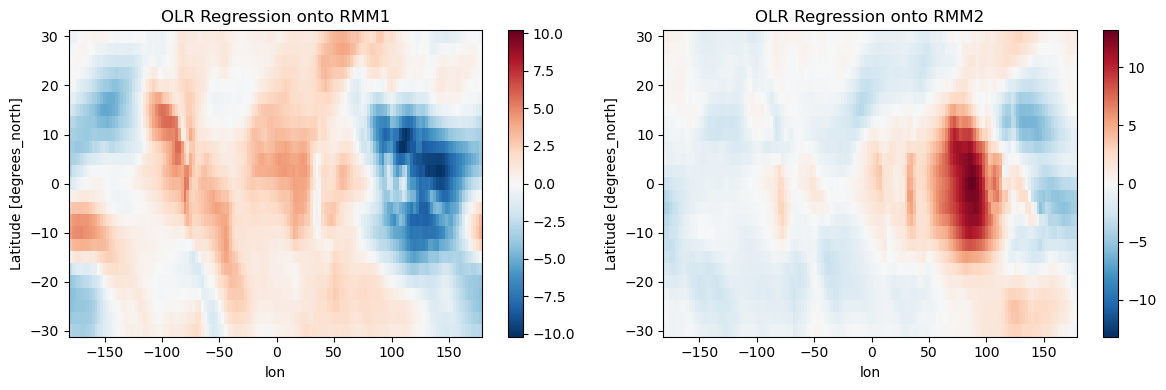

In [13]:
# Regression coefficient of OLR onto PC1 (RMM1), assuming zero intercept
rmm1_reg = ((olr_mjo * pc1_xr).mean("time")/ (pc1_xr ** 2).mean("time"))
rmm2_reg = ((olr_mjo * pc2_xr).mean("time")/ (pc2_xr ** 2).mean("time"))

rmm1_reg = rmm1_reg.assign_coords(lon=(((rmm1_reg.lon + 180) % 360) - 180)).sortby("lon")
rmm2_reg = rmm2_reg.assign_coords(lon=(((rmm2_reg.lon + 180) % 360) - 180)).sortby("lon")

## plotting
fig, ax = plt.subplots(1, 2, figsize=(12,4))

# RMM1 regression
rmm1_reg.plot(ax=ax[0], cmap="RdBu_r")
ax[0].set_title("OLR Regression onto RMM1")

# RMM2 regression
rmm2_reg.plot(ax=ax[1], cmap="RdBu_r")
ax[1].set_title("OLR Regression onto RMM2")

plt.tight_layout()
plt.show()

These represent:
- rmm1_reg(x,y): spatial pattern of OLR anomalies associated with RMM1
- rmm2_reg(x,y): spatial pattern of OLR anomalies associated with RMM2
  
**Note:** negative = enhanced convection (cloudiness) and positive = suppressed convection)

Each regression map corresponds to the OLR response to one standard deviation of the respective principal component.

The regression maps represent the spatial structure of OLR anomalies associated with each RMM mode. RMM1 and RMM2 together describe the canonical evolution of the MJO, with their combined patterns corresponding to the eastward propagation of enhanced and suppressed convection across the tropics. Because the regression is based on time covariance, the resulting patterns emphasize the coherent component of OLR variability that is linearly associated with the MJO, filtering out unrelated high-frequency noise.

In [14]:
# Some checks before moving further
#print(float(rmm1_reg.min()))
#print(float(rmm1_reg.max()))

#print(float(rmm2_reg.min()))
#print(float(rmm2_reg.max()))
#xr.corr(rmm1_reg, rmm2_reg)

##  Reconstruction of MJO Phase-Dependent Spatial Patterns

Once the regression patterns onto the two RMM principal components are obtained, we can reconstruct the spatial structure of the MJO associated with its canonical phases. The RMM phase space can be interpreted as a two-dimensional basis defined by RMM1 and RMM2, where different linear combinations correspond to different phases of the MJO cycle.

Using the regression maps onto RMM1 and RMM2, we construct phase-representative fields as linear combinations of these basis patterns. Phase fields are constructed as linear combinations of RMM1 and RMM2 regression patterns.

In [15]:
phase_1 = -rmm2_reg
phase_2 = (rmm1_reg - rmm2_reg) / np.sqrt(2)
phase_3 = rmm1_reg
phase_4 = (rmm1_reg + rmm2_reg) / np.sqrt(2)
phase_5 = rmm2_reg

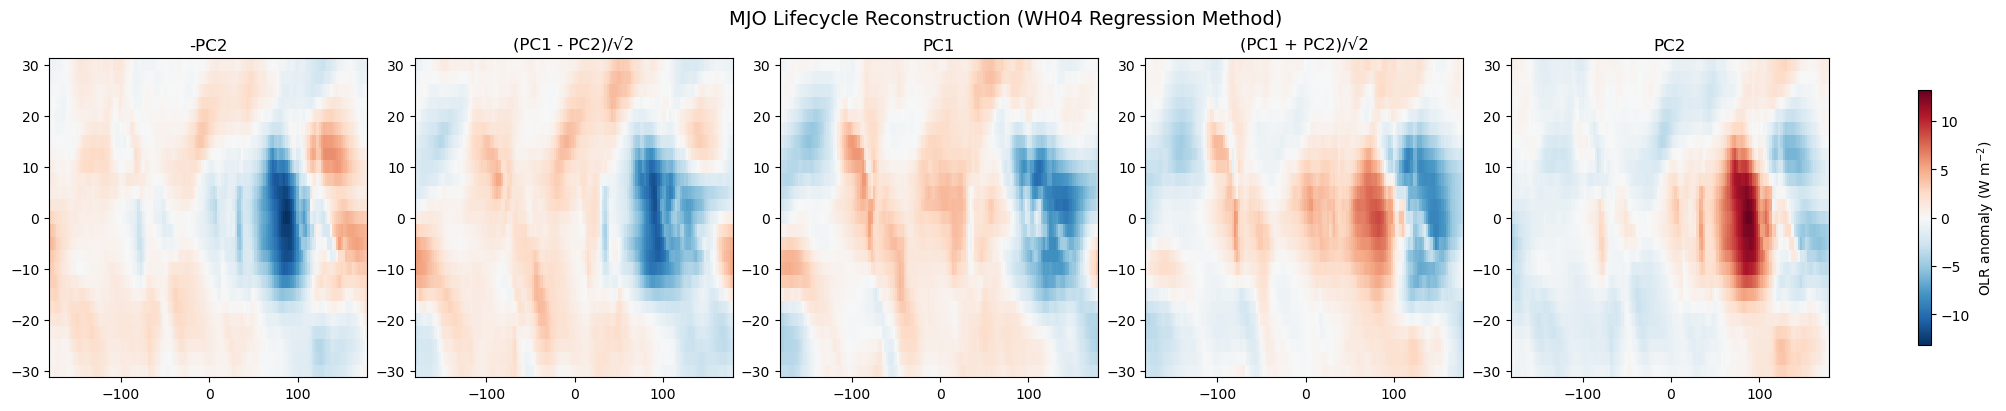

In [16]:
# plot the outputs
fig, axes = plt.subplots(1, 5, figsize=(20, 4), constrained_layout=True)

phases = [phase_1, phase_2, phase_3, phase_4, phase_5]
titles = [
    "-PC2",
    "(PC1 - PC2)/√2",
    "PC1",
    "(PC1 + PC2)/√2",
    "PC2"
]

vmin = min([p.min().values for p in phases])
vmax = max([p.max().values for p in phases])

for ax, data, title in zip(axes, phases, titles):
    im = data.plot(
        ax=ax,
        cmap="RdBu_r",
        vmin=vmin,
        vmax=vmax,
        add_colorbar=False
    )
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("")

# single shared colorbar
cbar = fig.colorbar(im, ax=axes, orientation="vertical", shrink=0.8)
cbar.set_label("OLR anomaly (W m$^{-2}$)")

fig.suptitle("MJO Lifecycle Reconstruction (WH04 Regression Method)", fontsize=14)

plt.show()

These phase combinations represent a rotation of the RMM1–RMM2 basis into phase space. The transformation highlights the eastward propagation of convection by expressing the MJO as successive projections along different angular directions in phase space.

##  Geographic visualization with Cartopy

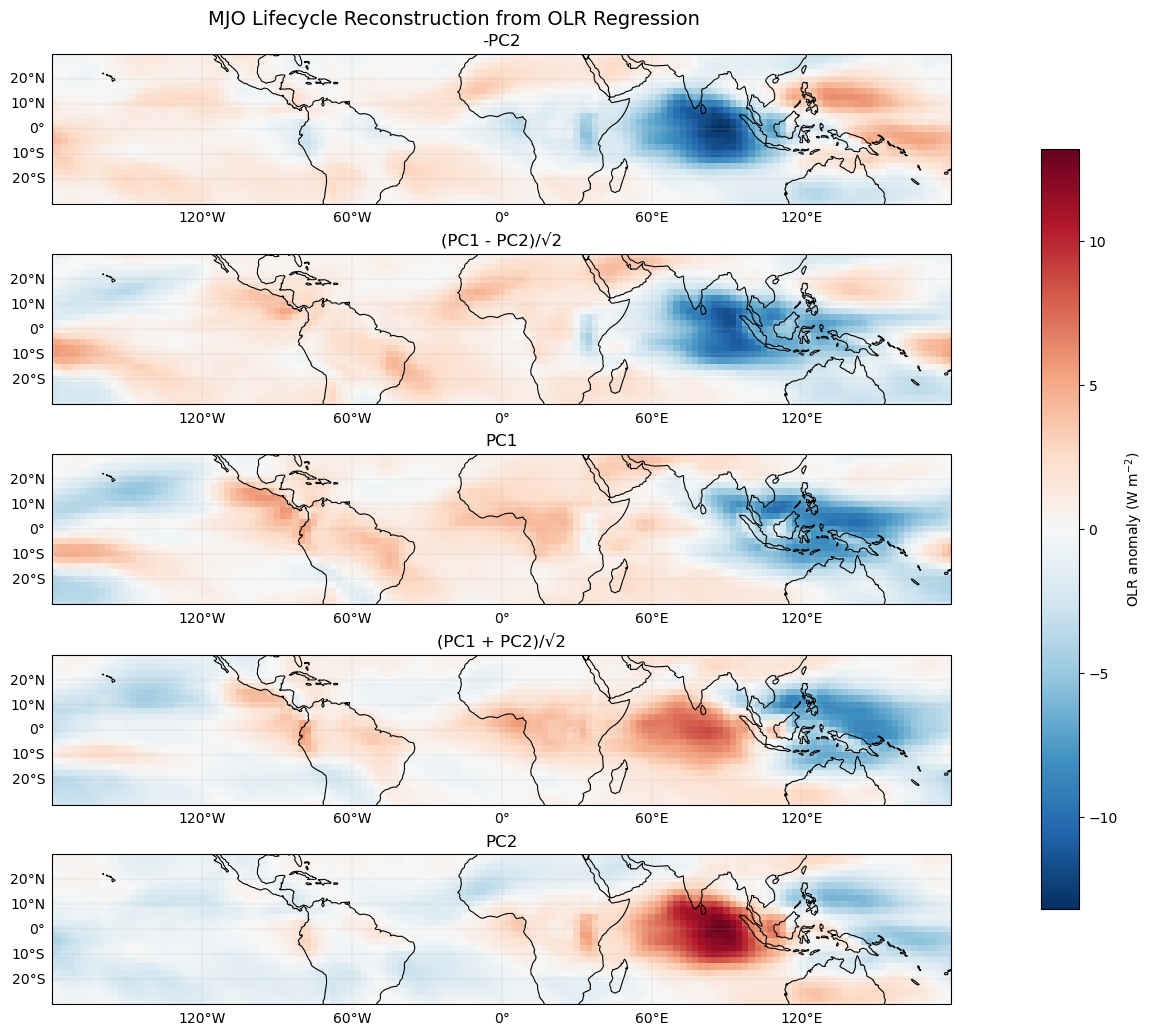

In [17]:
fig, axes = plt.subplots(
    5, 1,
    figsize=(20, 10),
    subplot_kw={"projection": ccrs.PlateCarree()},
    constrained_layout=True
)
for ax, data, title in zip(axes, phases, titles):

    im = data.plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap="RdBu_r",
        vmin=vmin,
        vmax=vmax,
        add_colorbar=False
    )

    ax.set_title(title)

    ax.coastlines(linewidth=0.8)
    ax.add_feature(cfeature.LAND, facecolor="lightgray", alpha=0.2)

    gl = ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)
    gl.top_labels = False
    gl.right_labels = False

    ax.set_extent([40, 280, -30, 30], crs=ccrs.PlateCarree())

cbar = fig.colorbar(im, ax=axes, orientation="vertical", shrink=0.8)
cbar.set_label("OLR anomaly (W m$^{-2}$)")

#fig.suptitle("MJO Lifecycle Reconstruction- using OLR", fontsize=14, ha="center")
fig.suptitle(
    "MJO Lifecycle Reconstruction from OLR Regression",
    fontsize=14,
    x=0.65,
    ha="center",
    y=1.02
)
plt.show()

These phase composites represent successive projections of the MJO structure in RMM phase space. Together, they illustrate the canonical evolution of tropical convection anomalies, highlighting the eastward propagation from the Indian Ocean through the Maritime Continent into the western Pacific.


### RMM Linear Combinations Interpretation
The linear combinations of RMM1 and RMM2 represent successive stages of the Madden–Julian Oscillation lifecycle in phase space. These projections capture the evolution of tropical convection from suppressed conditions over the Indian Ocean to enhanced convective activity over the Maritime Continent and western Pacific.

The −PC2 state corresponds to an initial suppressed phase over the Indian Ocean, followed by the (PC1 − PC2)/√2 transition phase indicating the onset of convection. The PC1 phase represents peak convective activity over the Indian Ocean, while the (PC1 + PC2)/√2 state marks the eastward propagation of convection toward the Maritime Continent. Finally, the PC2 phase reflects a mature MJO state, with strong convection over the Maritime Continent and Bay of Bengal extending toward New Guinea, and suppressed conditions persisting over the western Pacific.

Together, these combinations illustrate the canonical eastward propagation of the MJO as a rotation in RMM phase space.

## Summary
In this tutorial, we built a complete workflow to diagnose the Madden–Julian Oscillation (MJO) using observational data. Starting from raw OLR fields, we applied a sequence of preprocessing steps including gap filling, seasonal cycle removal, and intraseasonal filtering to isolate the MJO signal.

We then connected the filtered OLR variability to the Real-time Multivariate MJO (RMM) framework by extracting principal components and aligning them in a consistent time coordinate system. Using these components, we reconstructed the spatial structure of the MJO through regression onto RMM1 and RMM2.

Finally, we visualized the MJO lifecycle in multiple ways:

1. RMM phase-space evolution,
2. Regression maps of convection anomalies
3. Phase-based reconstruction of the full MJO cycle.

Together, these steps demonstrate how EOF-based methods and the RMM index provide a physically consistent description of tropical intraseasonal variability.

### What's next?
This framework can be extended to other fields such as precipitation and zonal winds to further diagnose the full dynamical structure and regional impacts of the MJO.